In [1]:
import jax
import jax.numpy as jnp
from flax import nnx
from pathlib import Path
import json
import unet_jax
from data import pad_frames_to_multiple
from diffusion import load_model as load_mlx_unet
from vae import encode_clips
from port_utils import _copy_mlx_unet_to_jax

import numpy as np
from PIL import Image
from video_utils import to_uint8_video


DEFAULT_MLX_UNET_DIR = Path(
    "/Users/smaug/dev/mini-dreamer-workspace/mini-dreamer/logs/vizdoom-latent-v2"
)
DEFAULT_MLX_VAE_DIR = Path(
    "/Users/smaug/dev/mini-dreamer-workspace/mini-dreamer/logs/vizdoom-vae"
)
JAX_VAE_DIR = Path(
    "logs/port-utils/vizdoom-vae/flax-vae"
)

unet_dir = Path(DEFAULT_MLX_UNET_DIR)
mlx_model = load_mlx_unet(unet_dir, prefer_ema=True)
config = json.loads((unet_dir / "config.json").read_text())
jax_model = unet_jax.UNet3D(**config, rngs=nnx.Rngs(0))
_copy_mlx_unet_to_jax(mlx_model, jax_model)

type(jax_model)

unet_jax.UNet3D

In [2]:
config

{'in_channels': 8,
 'out_channels': 3,
 'num_actions': 4,
 'base_channels': 32,
 'max_context_size': 7,
 'num_transformer_blocks': 4,
 'use_wavelet': False,
 'predict_reward': True,
 'vae_dir': 'logs/vizdoom-vae'}

In [3]:
from jax import random

b, t, h, w, c = 4, 8, 32, 32, 8
x_shape = (b,t, h,w,c)
key = random.key(0)
x = random.normal(key, x_shape, dtype=jnp.bfloat16)
t = jnp.ones(b,)
a = jnp.arange(b).reshape(b, -1)

out = jax_model(x,t,a)
out.shape

(4, 8, 32, 32, 8)

In [4]:
nnx.tabulate(jax_model, x,t,a)

                                                  UNet3D Summary                                                   
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ path                 ┃ type                 ┃ inputs               ┃ outputs              ┃ Param               ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│                      │ UNet3D               │ -                    │ float32[4,8,32,32,8] │ 3,600,713 (14.4 MB) │
│                      │                      │ bfloat16[4,8,32,32,… │                      │                     │
│                      │                      │ - float32[4]         │                      │                     │
│                      │                      │ - int32[4,1]         │                      │                     │
├──────────────────────┼──────────────────────┼──────────────────────┼──────────────────────┼─────────────────────┤
│ encode               │ UNet3D               │ -                    │ -                    │ 3,600,713 (14.4 MB) │
│                      │                      │ bfloat16[4,8,32,32,… │ float32[4,2,8,8,128] │                     │
│                      │                      │ - float32[4]         │ - -                  │                     │
│                      │                      │ - int32[4,1]         │ float32[4,8,32,32,3… │                     │
│                      │                      │ t_ctx: None          │   -                  │                     │
│                      │                      │                      │ float32[4,4,16,16,6… │                     │
│                      │                      │                      │ - float32[4,128]     │                     │
├──────────────────────┼──────────────────────┼──────────────────────┼──────────────────────┼─────────────────────┤
│ time_embed           │ TimeEmbedding        │ float32[4]           │ float32[4,128]       │ 131,776 (527.1 KB)  │
├──────────────────────┼──────────────────────┼──────────────────────┼──────────────────────┼─────────────────────┤
│ time_embed/fourier   │ GaussianFourierEmbe… │ float32[4]           │ float32[4,128]       │ weight: float32[64] │
│                      │                      │                      │                      │                     │
│                      │                      │                      │                      │ 64 (256 B)          │
├──────────────────────┼──────────────────────┼──────────────────────┼──────────────────────┼─────────────────────┤
│ time_embed/lin1      │ Linear               │ float32[4,128]       │ float32[4,512]       │ bias: float32[512]  │
│                      │                      │                      │                      │ kernel:             │
│                      │                      │                      │                      │ float32[128,512]    │
│                      │                      │                      │                      │                     │
│                      │                      │                      │                      │ 66,048 (264.2 KB)   │
├──────────────────────┼──────────────────────┼──────────────────────┼──────────────────────┼─────────────────────┤
│ time_embed/lin2      │ Linear               │ float32[4,512]       │ float32[4,128]       │ bias: float32[128]  │
│                      │                      │                      │                      │ kernel:             │
│                      │                      │                      │                      │ float32[512,128]    │
│                      │                      │                      │                      │                     │
│                      │                      │                      │                      │ 65,664 (262.7 KB)   │
├──────────────────────┼──────────────────────┼─────────

''

In [8]:
from diffusion import Dataset
from diffusion_jax import train_on_dataset, ModelConfig, TrainConfig
from video_utils import make_random_video_dataset

def train_overfit_random_noise(
    *,
    steps: int = 1_000,
    batch_size: int = 1,
    num_videos: int = 1,
    frames: int = 4,
    height: int = 32,
    width: int = 32,
    channels: int = 3,
    base_channels: int = 16,
    learning_rate: float = 1e-3,
    seed: int = 0,
    log_every: int = 50,
    sample_dir: str | Path | None = None,
    num_samples: int = 4,
    sample_steps: int = 32,
    sample_fps: float = 8.0,
):
    data_dir = "logs/vizdoom-vae-jax"
    dataset = Dataset(data_dir=data_dir, memory_map=True)
    return train_on_dataset(
        dataset,
        model_config=ModelConfig(base_channels=base_channels),
        train_config=TrainConfig(
            train_steps=steps,
            batch_size=batch_size,
            learning_rate=learning_rate,
            log_every=log_every,
            save_dir=sample_dir,
            num_gen_samples=num_samples,
            sample_steps=sample_steps,
        ),
    )

train_overfit_random_noise()

setup dataset from logs/vizdoom-vae-jax
self.train_size = 93 - self.val_size = 5
Using train config:
TrainConfig(train_steps=1000,
            batch_size=1,
            learning_rate=0.001,
            lr_final=None,
            lr_warmup_steps=500,
            lr_hold_steps=3000,
            ema_decay=0.99,
            action_dropout=0.1,
            reward_loss_weight=0.0,
            reward_t_threshold=0.6,
            min_context_t=0.5,
            log_every=50,
            save_dir=None,
            load_dir=None,
            num_gen_samples=4,
            sample_steps=32,
            sampling_distribution='uniform',
            log_tensorboard=False)
Using model config:
ModelConfig(in_channels=3,
            base_channels=16,
            max_context_size=3,
            num_transformer_blocks=2,
            use_wavelet=False,
            predict_reward=False)


NameError: name 'asdict' is not defined

In [7]:
def make_final_frame_mask(x: jnp.ndarray) -> jnp.ndarray:
    frame_mask = (jnp.arange(x.shape[1]) == (x.shape[1] - 1)).astype(x.dtype)
    return jnp.reshape(frame_mask, (1, x.shape[1], 1, 1, 1))

def sample_noise(
    key: jax.Array,
    shape: tuple[int, ...],
    noise_distribution,
    mu: float = 0.0,
    s: float = 1.0,
    dtype: jnp.dtype = jnp.float32,
) -> jnp.ndarray:
    """Unlike the MLX version, the RNG key is explicit: JAX has no global
    random state, so every draw consumes a key the caller controls."""
    match noise_distribution:
        case "logitnorm":
            return sample_t_logit_normal(key, shape, mu, s)

        case "normal":
            return random.normal(key, shape, dtype=dtype)

        case "uniform":
            return random.uniform(key, shape, dtype=dtype)

def _loss_at_t(
    self,
    model,
    x1,
    actions,
    t,
    *,
    t_ctx,
    rewards: jnp.ndarray | None = None,
    return_eval_aux: bool = False,
):
    """Flow-matching loss at the given t.

    By default returns ``(total_loss, reward_loss)`` where ``total_loss``
    is the flow loss plus ``reward_loss_weight * reward_loss``. The reward
    loss is an MSE on the final frame's reward, computed only when
    ``rewards`` (B,) is given and ``reward_loss_weight > 0``, and only over
    batch elements with ``t >= reward_t_threshold`` (near-clean inputs —
    heavily noised frames carry too little state to predict reward from).

    If ``return_eval_aux`` is True, returns ``(loss, recon_mse, x1_pred,
    r2)`` for eval/logging instead (flow loss only):

    - ``recon_mse``: MSE of the one-step x1 reconstruction
        ``x1_pred = xt + (1 - t) * v_pred``.
    - ``x1_pred``: the prediction itself, shape ``(B, 1, H, W, C)``.
    - ``r2``: ``1 - loss / E[target_velocity^2]`` — fraction of target
        variance explained, scale-free baseline.
    """
    mask = make_final_frame_mask(x1)
    if t_ctx is None:
        t_ctx = mx.ones_like(t)

    # Diffusion-forcing style corruption: the target (final) frame is noised
    # to level ``t`` while the conditioning frames are noised to level
    # ``t_ctx`` (1.0 = clean). Training on imperfect history teaches the
    # model to denoise from its own (error-carrying) rollout frames instead
    # of always-clean ground truth, which is what curbs autoregressive
    # drift. ``level`` is ``t`` on the final frame and ``t_ctx`` elsewhere.
    noise = sample_noise(x1.shape, noise_distribution="normal")
    t_view = jax.reshape(t, (x1.shape[0], 1, 1, 1, 1)) * mask
    t_ctx_view = jax.reshape(t_ctx, (x1.shape[0], 1, 1, 1, 1)) * (1 - mask)
    level = t_view + t_ctx_view
    xt = (1.0 - level) * noise + level * x1
    target_velocity = mask * (x1 - noise)
    
    xmid, skips, time_context = model.encode(xt, t, context=actions, t_ctx=t_ctx)
    pred_velocity = model.decode(xmid, skips, time_context)
    
    loss = mx.mean((pred_velocity[:, -1:] - target_velocity[:, -1:]) ** 2)
    
    if not return_eval_aux:
        reward_loss = mx.array(0.0)
        if rewards is not None and self.reward_loss_weight > 0.0:
            pred_reward = model.predict_reward(xmid)
            keep = (t >= self.reward_t_threshold).astype(loss.dtype)
            reward_loss = mx.mean(keep * (pred_reward - rewards) ** 2)
        return loss + self.reward_loss_weight * reward_loss, reward_loss

    x1_pred = xt[:, -1:] + (1.0 - level[:, -1:]) * pred_velocity[:, -1:]
    recon_mse = mx.mean((x1_pred - x1[:, -1:]) ** 2)
    target_var = mx.mean(target_velocity[:, -1:] ** 2)
    r2 = 1.0 - loss / mx.maximum(target_var, 1e-12)
    return loss, recon_mse, x1_pred, r2

In [ ]:
noise = random.normal()

In [5]:
from diffusion_jax import sample_euler
sample_euler?

Signature:
sample_euler(
    model: unet_jax.UNet3D,
    *,
    conditioning_clips: jax.Array,
    actions: jax.Array,
    num_steps: int = 32,
    return_intermediates: bool = False,
    seed: int = 0,
) -> jax.Array | list[jax.Array]
Docstring:
Run Euler integration to generate the next frame.

Args:
    return_intermediates: if True, return a list of ``(B, 1, H, W, C)``
        arrays — one snapshot of the noisy frame ``x`` after each Euler
        step — instead of the final concatenated clip.  Useful for
        visualising the denoising trajectory.
File:      ~/dev/jax-dreams/mini-dreamer/diffusion_jax.py
Type:      function

In [9]:
xrec = sample_euler(jax_model, conditioning_clips=x[:,:-1,...], actions=a)
xrec.shape

(4, 8, 32, 32, 8)

In [183]:
from port_utils import create_vizdoom_test_set

clips, actions, rewards, data_dir = create_vizdoom_test_set()
clips.shape, actions.shape

Loading precomputed rollouts from logs/port-utils/vizdoom-vae/test-set


WARNING! Loading config from: "config string". Unsupported key: continuous in line #1. Line ignored.


((426, 8, 240, 320, 3), (426, 8))

In [184]:
actions[0]

array([0, 3, 2, 3, 2, 0, 1, 0], dtype=int32)

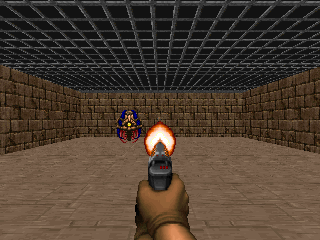

In [187]:
Image.fromarray(to_uint8_video(clips[0,-1]))

In [32]:
B, S, H, W, C = clips.shape
H/32, W/32

(7.5, 10.0)

In [66]:
from port_utils import export_flax_vae_checkpoint
export_flax_vae_checkpoint()

PosixPath('logs/port-utils/vizdoom-vae/flax-vae')

In [93]:
from vae_jax import load_vae, encode_clips, decode_latents
from data import pad_frames_to_multiple

vae = load_vae(JAX_VAE_DIR, prefer_ema=True)
# pad_frames_to_multiple takes (T, H, W, C); flatten the clip dims around it.

num_samples = 8
raw = jnp.array(clips[:8])
padded = pad_frames_to_multiple(
    raw.reshape(-1, *raw.shape[2:]), multiple=32
)
batch_np = padded.reshape(*raw.shape[:2], *padded.shape[1:])
latents = encode_clips(vae, batch_np)
actions = jnp.array(actions[:num_samples])

t_ctx = 1.0

In [94]:
latents.shape, actions.shape

((8, 8, 32, 40, 8), (8, 8))

In [95]:
xrec = sample_euler(jax_model, conditioning_clips=latents[:,:-1,...], actions=actions)
xrec.shape

(8, 8, 32, 40, 8)

In [90]:
rec = np.asarray(decode_latents(vae, xrec))
rec.shape

(8, 8, 256, 320, 3)

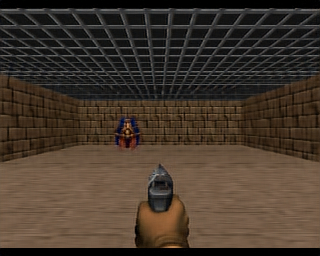

In [92]:

sample = Image.fromarray(to_uint8_video(rec[0,0]))
sample

In [177]:
def sample_euler_jax(
    model,
    conditioning_clips: jnp.ndarray,
    actions: jnp.ndarray,
    num_steps: int = 32,
    seed: int = 0,
) -> jnp.ndarray | list[jnp.ndarray]:

    if num_steps <= 0:
        raise ValueError(f"num_steps must be > 0, got {num_steps}")

    batch_size = conditioning_clips.shape[0]
    x_shape = (
        batch_size,
        1,
        int(conditioning_clips.shape[2]),
        int(conditioning_clips.shape[3]),
        int(conditioning_clips.shape[4]),
    )
    key = random.key(seed)
    x = random.normal(key, x_shape, dtype=conditioning_clips.dtype)
    eps = 1e-3
    # [eps, 1-eps) with num_steps equal partitions
    dt = (1 - 2 * eps) / num_steps
    # [eps, 1 - eps - eps] so that after final step x is at t = 1-eps
    ts = eps + jnp.arange(num_steps) * dt 
    intermediates: list[jnp.ndarray] = []

    def _step(xt_prev, step_i):
        t = jnp.full((batch_size,), step_i, dtype=conditioning_clips.dtype)
        xt = jnp.concatenate([conditioning_clips, xt_prev], axis=1)
        v = model(xt, t, context=actions)
        x = xt_prev + dt * v[:, -1:]
        return x, x
    
    ts = jnp.linspace(0,1,num_steps)
    x, _ = jax.lax.scan(_step, init=x, xs=ts)
            
    samples = jnp.concatenate([conditioning_clips, x], axis=1)
    return samples

In [156]:
%%time
xrec = sample_euler(jax_model, conditioning_clips=latents[:,:-1,...], actions=actions)
xrec.shape

CPU times: user 54 s, sys: 1.3 s, total: 55.3 s
Wall time: 4.47 s


(8, 8, 32, 40, 8)

In [180]:
%%time
xrec_scanned = sample_euler_jax(jax_model, conditioning_clips=latents[:,:-1,...], actions=actions, num_steps=28)
xrec_scanned.shape

CPU times: user 1.07 s, sys: 22.7 ms, total: 1.1 s
Wall time: 247 ms


(8, 8, 32, 40, 8)

In [153]:
# (xrec[:,-1,...]- xrec_scanned[:,-1,...])

In [155]:
# jnp.isclose(xrec[:,-1,...], xrec_scanned[:,-1,...])

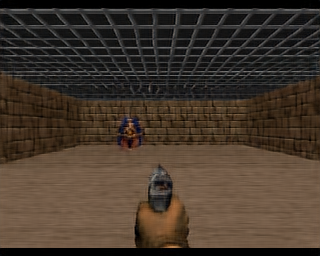

In [182]:
rec = np.asarray(decode_latents(vae, xrec_scanned))
sample = Image.fromarray(to_uint8_video(rec[0,-1]))
sample

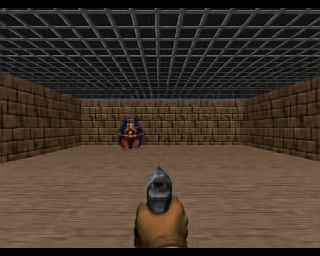

In [119]:
sample = Image.fromarray(to_uint8_video(rec[0,1]))
sample

In [130]:
actions[0]

Array([0, 3, 2, 3, 2, 0, 1, 0], dtype=int32)

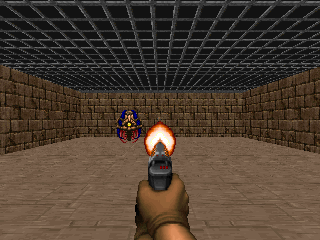

In [129]:
orig = Image.fromarray(to_uint8_video(clips[0,-1]))
orig

In [171]:
eps = 1e-3
num_steps = 8

dt = 1/num_steps

dt, [i/num_steps for i in range(num_steps)]

(0.125, [0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875])

In [172]:
jnp.linspace(0, 1, num_steps)

Array([0.        , 0.14285715, 0.2857143 , 0.42857146, 0.5714286 ,
       0.71428573, 0.8571429 , 1.        ], dtype=float32)

In [176]:
# Option A: num_steps evaluations, num_steps steps
dt = (1 - 2 * eps) / num_steps
ts = eps + jnp.arange(num_steps) * dt 
dt, ts, ts[-1]+dt

(0.12475,
 Array([0.001     , 0.12575   , 0.2505    , 0.37524998, 0.5       ,
        0.62475   , 0.7495    , 0.87425   ], dtype=float32, weak_type=True),
 Array(0.999, dtype=float32, weak_type=True))

In [169]:
ts = jnp.linspace(eps, 1 - eps, num_steps)
dt = (1 - 2 * eps) / (num_steps - 1)
dt, ts

(0.14257142857142857,
 Array([0.001     , 0.14357144, 0.28614286, 0.4287143 , 0.5712857 ,
        0.7138572 , 0.8564286 , 0.999     ], dtype=float32))